# Benchmark de compression sur le fichier SVS complet

Objectif : recompresser **toute la pyramide** en JPEG à différents quality levels, mesurer taille, temps, ratio.

In [ ]:
from pathlib import Path
import time
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd

DATA_DIR = Path("/Users/nath/Desktop/data_stage")
OUT_DIR = Path("./expe_debut_stage")
OUT_DIR.mkdir(exist_ok=True)

svs_files = sorted(DATA_DIR.glob("*.svs"), key=lambda p: p.stat().st_size)
SVS_PATH = svs_files[50]
orig_size = SVS_PATH.stat().st_size
print("Fichier :", SVS_PATH.name)
print("Taille originale :", round(orig_size / (1024*1024), 1), "Mo")

Fichier : TCGA-CD-A486-01Z-00-DX1.6FFE81CA-9074-44BC-B619-85A73BA61A2D.svs
Taille originale : 857.5 Mo


In [8]:
import openslide

slide = openslide.OpenSlide(str(SVS_PATH))
print(f"Niveaux : {slide.level_count}")
for i in range(slide.level_count):
    print(f"  Niveau {i} : {slide.level_dimensions[i]}  downsample x{slide.level_downsamples[i]:.1f}")
slide.close()

Niveaux : 4
  Niveau 0 : (67591, 88187)  downsample x1.0
  Niveau 1 : (16897, 22046)  downsample x4.0
  Niveau 2 : (4224, 5511)  downsample x16.0
  Niveau 3 : (2112, 2755)  downsample x32.0


## Fonction de recompression complète avec pyvips

On lit le SVS, on le resauvegarde en TIFF pyramidal JPEG.

In [9]:
import pyvips

def recompresser_svs(svs_path: Path, out_dir: Path, suffix: str, quality: int):
    """Recompresse un SVS entier en TIFF pyramidal JPEG."""
    out_path = out_dir / f"{svs_path.stem}_{suffix}.tiff"
    
    img = pyvips.Image.new_from_file(str(svs_path))
    
    t0 = time.perf_counter()
    img.tiffsave(
        str(out_path),
        tile=True, tile_width=256, tile_height=256,
        pyramid=True,
        compression="jpeg",
        Q=quality
    )
    dt = time.perf_counter() - t0
    
    size = out_path.stat().st_size
    ratio = orig_size / size
    
    print(f"\n--- {suffix} ---")
    print(f"  Taille : {size/(1024*1024):.1f} Mo")
    print(f"  Ratio  : {ratio:.2f}x (vs original)")
    print(f"  Temps  : {dt:.1f} s")
    
    return {
        "methode": suffix,
        "qualite": quality,
        "taille_Mo": round(size/(1024*1024), 1),
        "ratio": round(ratio, 2),
        "temps_s": round(dt, 1)
    }

## Tests de recompression

In [ ]:
results = []

# Original (ref)
results.append({
    "methode": "ORIGINAL SVS",
    "qualite": None,
    "taille_Mo": round(orig_size/(1024*1024), 1),
    "ratio": 1.0,
    "temps_s": 0.0
})

# JPEG Q=90 (on s'attend à ce que ce soit plus gros et c'est le cas)
results.append(recompresser_svs(SVS_PATH, OUT_DIR, "jpeg_q90", 90))

# JPEG Q=80
results.append(recompresser_svs(SVS_PATH, OUT_DIR, "jpeg_q80", 80))

# JPEG Q=70
results.append(recompresser_svs(SVS_PATH, OUT_DIR, "jpeg_q70", 70))

# JPEG Q=60
results.append(recompresser_svs(SVS_PATH, OUT_DIR, "jpeg_q60", 60))

# JPEG Q=50
results.append(recompresser_svs(SVS_PATH, OUT_DIR, "jpeg_q50", 50))


--- jpeg_q90 ---
  Taille : 2546.7 Mo
  Ratio  : 0.34x (vs original)
  Temps  : 36.8 s

--- jpeg_q80 ---
  Taille : 771.0 Mo
  Ratio  : 1.11x (vs original)
  Temps  : 33.4 s

--- jpeg_q70 ---
  Taille : 646.6 Mo
  Ratio  : 1.33x (vs original)
  Temps  : 33.4 s

--- jpeg_q60 ---
  Taille : 571.5 Mo
  Ratio  : 1.50x (vs original)
  Temps  : 33.6 s

--- jpeg_q50 ---
  Taille : 516.5 Mo
  Ratio  : 1.66x (vs original)
  Temps  : 33.3 s


## Tableau récapitulatif et graphique

,methode,qualite,taille_Mo,ratio,temps_s
0,ORIGINAL SVS,NaN,857.5,1.00,0.0
1,jpeg_q90,90.0,2546.7,0.34,36.8
2,jpeg_q80,80.0,771.0,1.11,33.4
3,jpeg_q70,70.0,646.6,1.33,33.4
4,jpeg_q60,60.0,571.5,1.50,33.6
5,jpeg_q50,50.0,516.5,1.66,33.3


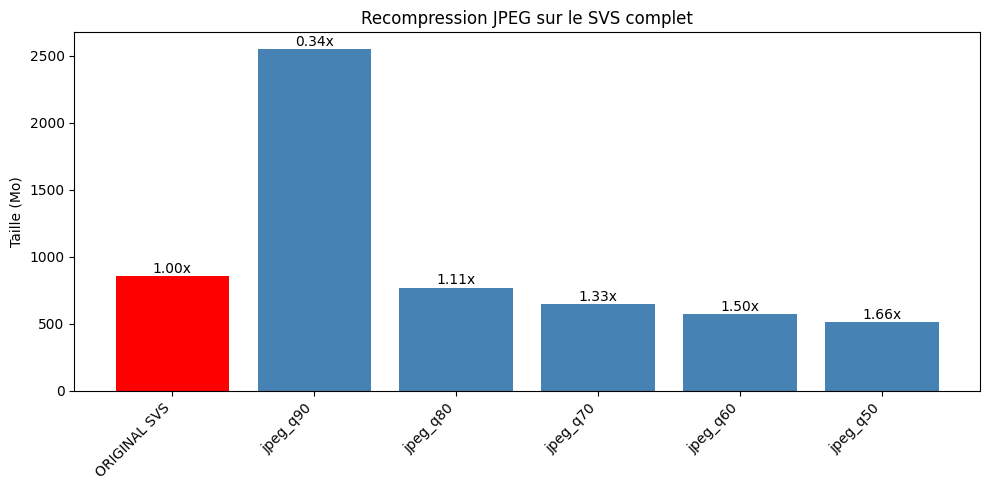

In [11]:
df = pd.DataFrame(results)
display(df)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["red" if r == "ORIGINAL SVS" else "steelblue" for r in df["methode"]]
bars = ax.bar(df["methode"], df["taille_Mo"], color=colors)
ax.set_ylabel("Taille (Mo)")
ax.set_title("Recompression JPEG sur le SVS complet")

for bar, ratio in zip(bars, df["ratio"]):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.5,
            f"{ratio:.2f}x", ha="center", va="bottom", fontsize=10)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Observation attendue

- **Q=90** : probablement **plus gros** que l'original (l'original est déjà compressé en JPEG Q≈70-80, recompresser à Q=90 ajoute de la taille sans gain)
- **Q=80** : légèrement plus petit ou proche
- **Q=70** : gain modéré
- **Q=60, 50** : gain significatif mais perte de qualité possible

Le ratio inférieur à 1.0 signifie "plus gros que l'original".